# Assignment 3: LLMs and Machine Learning

### Task 0: Setting Up Ollama

In [3]:
#a) 
from openai import OpenAI

client = OpenAI(
    base_url = "http://localhost:11434/v1/",
    api_key = "ollama" 
)
MODEL270 = "gemma3:270m"
MODEL4B = "gemma3:4b"


def ask_llm(prompt, model): 
    response = client.chat.completions.create(
        model = model, 
        messages = [{"role": "user", "content": prompt}]
    )

    return response.choices[0].message.content

#b)
print("Model: gemma3:270m")
print(ask_llm("What is machine learning? Give a short answer", MODEL270))


#c) 
print("Model: gemma3:4b")
print(ask_llm("What is the weather forecast for the 4 of May 2026 in London?", MODEL4B))

Model: gemma3:270m
Machine learning is a type of artificial intelligence (AI) that leverages algorithms and data to make predictions, decisions, or automate tasks. 

Model: gemma3:4b
Okay, let's look at the weather forecast for London on May 4th, 2026.

**Please note:**  Predicting weather that far out (over two years) is *extremely* difficult. Weather models become less accurate as the date moves further into the future. The information below is a *best-guess* based on current weather models and trends, but it should be taken with a *huge* grain of salt.

**Here's what the most reliable forecasts currently suggest as of November 2, 2023:**

*   **Temperature:** Highs of around 17-19°C (63-66°F), lows of around 11-13°C (52-55°F).
*   **Conditions:** Mostly cloudy with a 60-70% chance of showers at some point throughout the day. There is a 30-40% chance of brief periods of sunshine. 
*   **Wind:** Moderate winds from the west at 15-25 mph (24-40 km/h).
*   **Rain:** Showers are likely t

### Task 1: Text Classification with Ollama

In [5]:
import pandas as pd

emails = pd.read_csv("emails.csv", sep=";") #there are commas in the data that are confusing python, sep helps with that problem

#a)

CATEGORIES = ["Scam", "Not Scam"]

def classify_emails(text, model): 
    """Classify whether an email is a scam or not and sort it into the corrersponding category"""
    categories_str = ", ".join(CATEGORIES)
    prompt = f"""Classify the following emails based on their headlines into exactly one of these categories: {categories_str}.
Respond with only the category name nothing else. 

Message:{text}"""
    result = ask_llm(prompt, model) 
    return result.strip()
    
#b) 
print("b) Model gemma3:270m")
print(emails["headline"].apply(lambda x: classify_emails(x, MODEL270)))

#c) 
print("c) Model: gemma3:4b")
print(emails["headline"].apply(lambda x: classify_emails(x, MODEL4B)))


b) Model gemma3:270m
0     Not Scam
1     Not Scam
2     Not Scam
3     Not Scam
4     Not Scam
5     Not Scam
6     Not Scam
7     Not Scam
8     Not Scam
9     Not Scam
10    Not Scam
11    Not Scam
Name: headline, dtype: object
c) Model: gemma3:4b
0         Scam
1         Scam
2         Scam
3         Scam
4     Not Scam
5     Not Scam
6     Not Scam
7     Not Scam
8     Not Scam
9     Not Scam
10        Scam
11        Scam
Name: headline, dtype: object


It seems that the smaller gemma:270m is not able to correctly classify the emails, it is classifying all of them as Not Scam. Gemma3:4b on the other hand is classifying half of them, 6 out of 12, as Scam emails. When looking at the dataset the gemmma3:4b model seems to be doing okay. The two last emails in the list might not be scams but it is difficult to see only from the headline because it is quite vague. 

In [7]:
#d) 

print("d)")
results = {"headline": emails["headline"]} 

for i in range(1, 4):
    results[f"run{i}_270m"]= emails["headline"].apply(lambda x: classify_emails(x, MODEL270))
    results[f"run{i}_4b"]= emails["headline"].apply(lambda x: classify_emails(x, MODEL4B))

results_df = pd.DataFrame(results)
print(results_df)

d)
                                             headline run1_270m   run1_4b  \
0   URGENT: Your account will be suspended within ...  Not Scam      Scam   
1   Congratulations! You have won a 1000€ gift car...  Not Scam      Scam   
2   Hot singles in your area are waiting to meet y...  Not Scam      Scam   
3   Re: Inheritance transfer of 4.5M USD pending y...  Not Scam      Scam   
4        Meeting agenda for Thursday's project review  Not Scam  Not Scam   
5   Q3 budget report attached, please review by Fr...  Not Scam  Not Scam   
6   Reminder: Annual performance review scheduled ...  Not Scam  Not Scam   
7   Updated draft of the manuscript, comments welcome  Not Scam  Not Scam   
8                      Quick question about last week  Not Scam  Not Scam   
9                                        Following up  Not Scam  Not Scam   
10    Important update regarding your recent activity  Not Scam      Scam   
11                                 Are you available?  Not Scam      Scam

From these results it can be seen that gemmma3:270m is not at all capable at classifying these emails. For each of these four runs it just classifies all the emails as scams. In the second run of gemma3:270m it made up its own category called suspended. This model is not at all reliable nor capable for this task. For gemma3:4b it can be seen that classifies the emails the same way for each run. This more complex model seems to be better at following the instructions, it is capable at classifying these emails into the categories of Scam and Not Scam. 

### Task 2: Sentiment Analysis with Ollama

In [ ]:
import json

news = pd.read_csv("news.csv",sep=";")

#a)

TOPICS = ["Earnings", "Mergers", "Regulation", "Macroeconomics"]

def analyse_news(text, model):
    """Classify news based on the topic and sentiment"""
    topics_str = ", ".join(TOPICS)
    prompt = f"""Classify these news based on topic and analyse the sentiment. 
Return only a JSON object, nothing but the raw JSON object: 
- "Topic": one of these topics:{topics_str} 
- "Sentiment": one of "Positive", "Negative", or "Neutral"

Review:{text}"""
    result = ask_llm(prompt, model) 
    result = result.replace("```json", "").replace("```", "").strip() #this part was added because of problems with the model not returning raw json even though I prompted that. 
    try:
        return json.loads(result)
    except:
        return {"Topic": "Unknown", "Sentiment": "Unknown"}

#b)
news_results = news["headline"].apply(lambda x: analyse_news(x, MODEL4B))

analysis_df = pd.DataFrame({
    "headline": news["headline"],
    "topic": news_results.apply(lambda x: x["Topic"]),
    "sentiment": news_results.apply(lambda x: x["Sentiment"])
})

print(analysis_df)

c) 
I used Claude AI to complete this. 


Here is my prompt: 


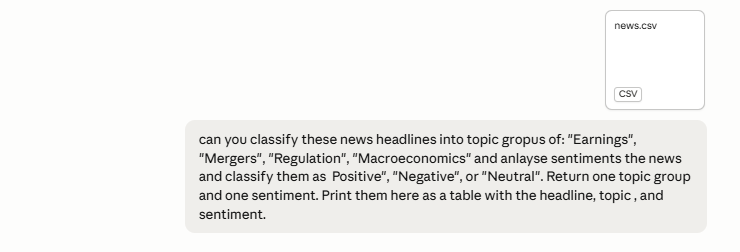


Here are the results: 


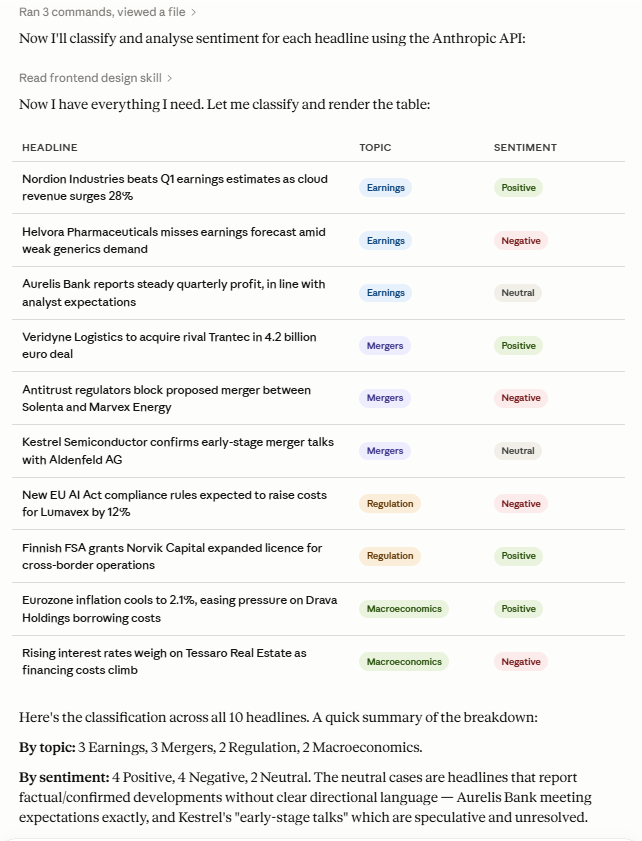

When comparing the results from the gemma3:4b and Claude it can be seen that they are mostly classifying the news headlines as belonging to the same topic. The only news headline where they have given a different answer in terms of topic is the 4th one ("Antitrust regulators block proposed merger bet... "). This one might be quite tricky for AI because it contain both regulator and merger in the headline. However, when looking at the sentiment analysis, the models have give different answers. They have given 7 of the headlines the same sentiments and for the rest they are of differing opinions. Having one of the categories being neutral peobably makes it more difficult for AI to distinguish between the categories. For all the headlines where the AI models had different answers it was because one of the models considered the headline as neutral and the other one did not.   

### Task 3: Supervised Machine Learning

#### a) Exploratory Data Analysis

In [ ]:
#importing and converting the additonal bank data that I dowloaded as a zip-file from UCI
import pandas as pd
import zipfile

with zipfile.ZipFile(r"C:\Users\sandr\Documents\Jupyter\bank-additional.zip", "r") as z:
    print(z.namelist())

with zipfile.ZipFile(r"C:\Users\sandr\Documents\Jupyter\bank-additional.zip", "r") as z:
    with z.open("bank-additional/bank-additional.csv") as f:
        bankdata = pd.read_csv(f, sep = ";")
        

In [ ]:
#a) exploratory data analysis
print(bankdata.isna().sum())

There does not seem to be any missing values so we do not need to handle that for this data. I will look through the data a bot more to check if there are other variables that needs to be changed. As can be seen below, there are quite a few variables that have string as their value. These need to be encoded as dummy variables. 

In [ ]:
bankdata.head()

In [ ]:
bankdata.info()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

bankdata.hist(figsize=(15, 10))
plt.tight_layout()

In [ ]:
sns.heatmap(bankdata.select_dtypes(include="number").corr(), annot=True, fmt=".2f")

#### b) Preprocessing

In [ ]:
#encoding the variables 
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder

#ordinal columns

enc = OrdinalEncoder(categories=[
    ["illiterate", "basic.4y", "basic.6y", "basic.9y", "high.school", "professional.course", "university.degree", "unknown"],
                                 ["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"], ["mon", "tue", "wed", "thu", "fri"]
])

bankdata[["education", "month", "day_of_week"]] = enc.fit_transform(bankdata[["education", "month", "day_of_week"]])

#y is made with label encoder because y cannot be split into different columns
le_y = LabelEncoder()
bankdata["y"] = le_y.fit_transform(bankdata["y"])

#one-hot encoding
bankdata = pd.get_dummies(bankdata, drop_first = True, dtype = float)

print("First five rows of BankData with only numerical columns:")
pd.set_option("display.max_columns", None)
bankdata.head()

In [ ]:
#scaling data

from sklearn.preprocessing import StandardScaler

for_scaling = ["age", "duration", "pdays", "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
scaler_standard = StandardScaler()

bankdata[for_scaling] = scaler_standard.fit_transform(bankdata[for_scaling])


#### c) Machine Learning Algorithms 

In [ ]:
#splitting the data into train-test-val
from sklearn.model_selection import train_test_split

X = bankdata.drop(columns = ["y"])
y = bankdata["y"]

#first split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#second split
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size = 0.25, random_state = 42)

print("Train set size:", X_train.shape[0])
print("Validation set size:", X_val.shape[0])
print("Test set size:", X_test.shape[0])
print("\nClass balance (train):")
print(y_train.value_counts())


This problem is a classification problem since the output variable is a yes/no (or after encoding a binary variable). Regression will predict a number but in this we want to predict which group of yes and no an observation is belonging to. The models that I will use are classifiaction tree, a classification tree with random forest, and SVC. 

In [ ]:
# Classfication Tree
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix

des_model = DecisionTreeClassifier(random_state = 42)
des_model.fit(X_train, y_train)

y_pred_des = des_model.predict(X_val)

In [ ]:
#Random Forest Model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state = 42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

In [ ]:
#SVM model
from sklearn.svm import SVC

svm_model = SVC(random_state = 42, class_weight = "balanced")
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_val)

In [ ]:
#scoes
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

for name, y_pred in [("Decision Tree", y_pred_des), ("Random Forest", y_pred_rf), ("SVM", y_pred_svm)]:
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_val, y_pred):.4f}")
    print(f"Precision: {precision_score(y_val, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_val, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_val, y_pred):.4f}")
    print()
    
#confusion matrices 

print("Confusion Matrices:")
for name, y_pred in [("Decision Tree", y_pred_des), ("Random Forest", y_pred_rf), ("SVM", y_pred_svm)]:
    cm = confusion_matrix(y_val, y_pred)
    print(f"{name} Confusion Matrix:")
    print(cm)
    print()


In [ ]:
#grid search to improve hyperparameters
from sklearn.model_selection import GridSearchCV

#DecisionTree
print("Decision Tree")
param_grid_des = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

grid_des = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_des, cv=5, scoring="recall", n_jobs=-1)
grid_des.fit(X_train, y_train)

print("Best DT parameters:", grid_des.best_params_)
print("Best DT Recall (CV):", f"{grid_des.best_score_:.4f}")

# Evaluate on validation set
y_pred_dt_tuned = grid_des.best_estimator_.predict(X_val)
print("Validation Recall:", f"{recall_score(y_val, y_pred_dt_tuned):.4f}")

#RandomForest
print("RandomForest")
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "bootstrap": [True, False]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring="recall", n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Best RF parameters:", grid_rf.best_params_)
print("Best RF Recall (CV):", f"{grid_rf.best_score_:.4f}")

# Evaluate on validation set
y_pred_rf_tuned = grid_rf.best_estimator_.predict(X_val)
print("Validation Recall:", f"{recall_score(y_val, y_pred_rf_tuned):.4f}")

#SVM
print("SVM")

param_grid_svm = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01, 0.1],
    "kernel": ["rbf"]
}
grid_svm = GridSearchCV(SVC(random_state=42, class_weight="balanced"), param_grid_svm, cv=5, scoring="recall", n_jobs=-1)
grid_svm.fit(X_train, y_train)
print("Best SVM parameters:", grid_svm.best_params_)
print("Best SVM Recall (CV):", f"{grid_svm.best_score_:.4f}")

# Evaluate on validation set
y_pred_svm_tuned = grid_svm.best_estimator_.predict(X_val)
print("Validation Recall:", f"{recall_score(y_val, y_pred_svm_tuned):.4f}")

In [ ]:
#final evaluation after tuning

#Decision Tree
y_pred_des_final = grid_des.best_estimator_.predict(X_test)

print("--- Final Decision Tree (Test Set) ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_des_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_des_final):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_des_final):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_des_final):.4f}")

#RandomForest
y_pred_rf_final = grid_rf.best_estimator_.predict(X_test)

print("--- Final Random Forest (Test Set) ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_final):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf_final):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_rf_final):.4f}")

#SVM
y_pred_svm_final = grid_svm.best_estimator_.predict(X_test)

print("--- Final SVM (Test Set) ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_svm_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm_final):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_svm_final):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_svm_final):.4f}")



#### d) Comparing with cross validation

In [ ]:
from sklearn.model_selection import cross_val_score

best_des = grid_des.best_estimator_
best_rf = grid_rf.best_estimator_
best_svm = grid_svm.best_estimator_

cv_des = cross_val_score(best_des, X, y, cv = 5, scoring = "recall")
cv_rf = cross_val_score(best_rf, X, y, cv = 5, scoring = "recall")
cv_svm = cross_val_score(best_svm, X, y, cv = 5, scoring = "recall")

print("Decision Tree CV Recall:", f"{cv_des.mean():.4f} (+/- {cv_des.std():.4f})")
print("Random Forest CV Recall:", f"{cv_rf.mean():.4f} (+/- {cv_rf.std():.4f})")
print("SVM CV Recall:", f"{cv_svm.mean():.4f} (+/- {cv_svm.std():.4f})")

In [ ]:
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "SVM"],
    "Test Set Recall": [recall_score(y_test, y_pred_des_final),
                        recall_score(y_test, y_pred_rf_final),
                        recall_score(y_test, y_pred_svm_final)],
    "CV Recall (mean)": [cv_des.mean(), cv_rf.mean(), cv_svm.mean()],
    "CV Std": [cv_des.std(), cv_rf.std(), cv_svm.std()]
})
print(results)

#### e) Evaluation 

The SVM is the best performing model, but the RandomForest model has the smallest difference in results between using set validation and cross-validation. It is also interesting to see that the normal decision tree is performing better than the RandomForest. Usually the RandomForest would imporve the results from a normal Classiying tree but here that is not the case. The accuracy is very high for the models but the recall is a lot lower. 

### AI Disclosure

I have used AI in this assignment for the parts of the assignment where AI was a part of the assignment. I have also used AI as help with solving errors or parts where I could not figure out the correct code. The AI model I have used is Claude AI.